Reddit Nepse Word Cloud

In [18]:
!pip install requests pandas wordcloud matplotlib -q


In [19]:
import time
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import requests


SUBREDDITS = [
    "NepalStock",
    "nepse",
    "Nepal",
]

MAX_PAGES_PER_SUB = 10    # 10 pages x 100 posts = 1000 posts per subreddit
OUTPUT_DIR        = "scraped_data"


BASE_URL = "https://api.pullpush.io/reddit/search/submission/"
HEADERS  = {"User-Agent": "NepseScraper/1.0"}


def fetch_page(subreddit, before=None):
    params = {
        "subreddit"  : subreddit,
        "size"       : 100,
        "sort"       : "desc",
        "sort_type"  : "created_utc",
    }
    if before:
        params["before"] = before
    resp = requests.get(BASE_URL, params=params, headers=HEADERS, timeout=30)
    resp.raise_for_status()
    return resp.json().get("data", [])


def scrape_subreddit(subreddit):
    all_posts = []
    before    = None

    print(f"\nScraping r/{subreddit} ...")

    for page in range(MAX_PAGES_PER_SUB):
        try:
            posts = fetch_page(subreddit, before=before)
        except Exception as e:
            print(f"  Error on page {page}: {e}")
            break

        if not posts:
            print(f"  No more posts found.")
            break

        all_posts.extend(posts)
        before  = posts[-1].get("created_utc", 0)
        oldest  = datetime.fromtimestamp(before, tz=timezone.utc).strftime("%Y-%m-%d")
        print(f"  Page {page+1}: +{len(posts)} posts | total: {len(all_posts)} | oldest: {oldest}")

        if len(posts) < 100:
            break
        time.sleep(1)

    # remove duplicates
    seen   = set()
    unique = [p for p in all_posts if p.get("id") not in seen and not seen.add(p.get("id"))]
    print(f"  Done: {len(unique)} unique posts from r/{subreddit}")
    return unique


def to_dataframe(posts, subreddit):
    rows = []
    for p in posts:
        created  = datetime.fromtimestamp(p.get("created_utc", 0), tz=timezone.utc)
        selftext = (p.get("selftext") or "").strip()
        if selftext in ("[removed]", "[deleted]"):
            selftext = ""
        rows.append({
            "subreddit"   : subreddit,
            "id"          : p.get("id", ""),
            "title"       : p.get("title", ""),
            "author"      : p.get("author", "[deleted]"),
            "selftext"    : selftext,
            "score"       : p.get("score", 0),
            "num_comments": p.get("num_comments", 0),
            "created_utc" : created,
            "permalink"   : "https://reddit.com" + p.get("permalink", ""),
            "flair"       : p.get("link_flair_text") or "",
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        df.sort_values("created_utc", ascending=False, inplace=True)
        df.reset_index(drop=True, inplace=True)
    return df


Path(OUTPUT_DIR).mkdir(exist_ok=True)
frames = []

for sub in SUBREDDITS:
    raw = scrape_subreddit(sub)
    df  = to_dataframe(raw, sub)
    if df.empty:
        print(f"  No data for r/{sub}, skipping.")
        continue
    frames.append(df)
    path = f"{OUTPUT_DIR}/{sub.lower()}.csv"
    df.to_csv(path, index=False)
    print(f"  Saved: {path} ({len(df)} rows)")

# combine all into one file
combined = pd.concat(frames, ignore_index=True)
combined.sort_values("created_utc", ascending=False, inplace=True)
combined.to_csv(f"{OUTPUT_DIR}/all_nepse.csv", index=False)

print(f"\nDone! Total posts scraped: {len(combined)}")
print(combined["subreddit"].value_counts().to_string())
print(f"\nFiles saved in: {OUTPUT_DIR}/")


Scraping r/NepalStock ...
  Page 1: +100 posts | total: 100 | oldest: 2025-04-27
  Page 2: +100 posts | total: 200 | oldest: 2025-04-10
  Page 3: +100 posts | total: 300 | oldest: 2025-03-25
  Page 4: +100 posts | total: 400 | oldest: 2025-03-14
  Page 5: +100 posts | total: 500 | oldest: 2025-03-03
  Page 6: +100 posts | total: 600 | oldest: 2025-02-22
  Page 7: +100 posts | total: 700 | oldest: 2025-02-06
  Page 8: +100 posts | total: 800 | oldest: 2025-01-21
  Page 9: +100 posts | total: 900 | oldest: 2025-01-07
  Page 10: +100 posts | total: 1000 | oldest: 2024-12-27
  Done: 920 unique posts from r/NepalStock
  Saved: scraped_data/nepalstock.csv (920 rows)

Scraping r/nepse ...
  Page 1: +5 posts | total: 5 | oldest: 2017-07-08
  Done: 5 unique posts from r/nepse
  Saved: scraped_data/nepse.csv (5 rows)

Scraping r/Nepal ...
  Page 1: +100 posts | total: 100 | oldest: 2025-05-08
  Page 2: +100 posts | total: 200 | oldest: 2025-05-07
  Page 3: +100 posts | total: 300 | oldest: 2025

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud,STOPWORDS
import re
df = pd.read_csv("/content/scraped_data/all_nepse.csv")
print(f"The total Posts: {len(df)}")
print(df['subreddit'].value_counts())

The total Posts: 1802
subreddit
NepalStock    920
Nepal         877
nepse           5
Name: count, dtype: int64


Generating the Word Cloud

In [21]:
text = " ".join(df['title'].dropna().tolist())
### Cleaning the Text::
text = re.sub(r"http\s|www\S+"," ",text)## it remove the url
text = re.sub(r"[^a-zA-Z\s]"," ",text)## letters only
text = re.sub(r"\b\w{1,2\b}"," ",text) ## remove 1-2 letter words
text = re.sub(r"\s+"," ",text).strip()

In [22]:
### stoping the words::
stopwords = set(STOPWORDS)
stopwords.update(["will","just","like","get","one","also","would","could","really","now","see","help","back","good","new","https","www","com","reddit","amp","deleted","removed",])


In [23]:
### Generating the  Word Cloud ::
wc = WordCloud(
    width = 1400,
    height = 800,
    background_color= "white",
    colormap = "tab20",
    stopwords = stopwords,
    max_words = 100,
    min_font_size = 10,
    max_font_size = 160,
    prefer_horizontal= 0.7,
    random_state = 42,
).generate(text)

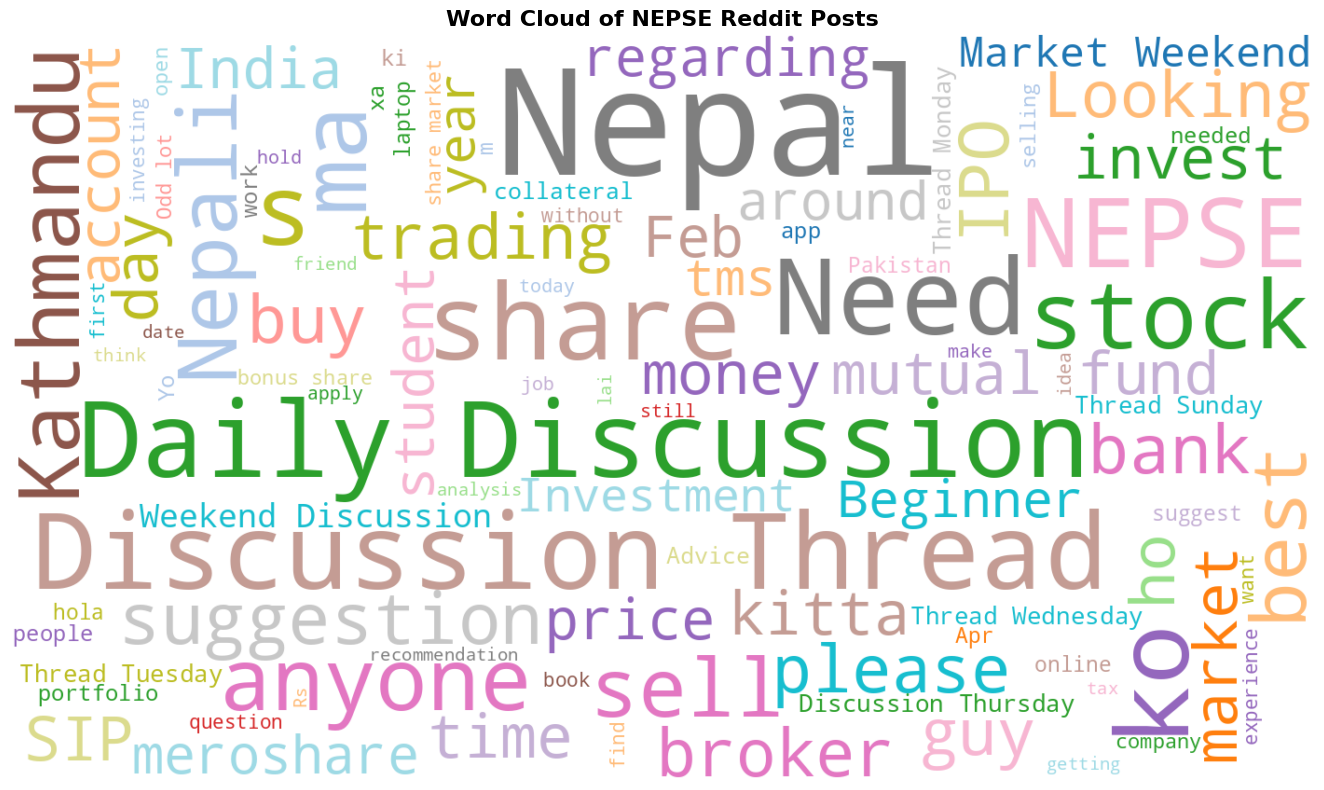

Saved Image Succesfully! 


In [24]:
## now saving and Showing::
plt.figure(figsize=(14,8))
plt.imshow(wc,interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of NEPSE Reddit Posts",fontsize = 16,fontweight ="bold")
plt.tight_layout()
plt.savefig("nepse_wordcloud.png",dpi=150,bbox_inches = "tight")
plt.show()
print("Saved Image Succesfully! ")

## Conclusion::
The NEPSE Reddit community is predominantly made up of beginner investors who are actively seeking advice on buying, selling shares, and applying for IPOs. The high frequency of words like "share", "stock", "bank", "mutual fund", and "SIP" indicates that banking sector stocks, IPO applications, and SIP investments are the most discussed topics. Words such as "broker", "meroshare", and "TMS" suggest many users are still learning the technical side of investing platforms rather than doing deep market analysis. The mixed use of Nepali words like "kitta", "ko", and "ma" alongside English reflects the bilingual nature of the community. Overall, the word cloud reveals that the NEPSE investor community on Reddit is young, learning-oriented, and heavily focused on short term trading decisions rather than long term fundamental analysis.